Sample X (Study Hours): [4.37086107 9.55642876 7.58794548 6.38792636 2.40416776]
Sample y (Exam Scores): [62.28954069 86.28710704 78.39853126 62.00178722 50.92247938]
Shape of X: (100,) Shape of y: (100,)
Min of X: 1.05 Min of y: 42.44
Max of X: 9.88 Max of y: 93.32
Mean of X: 5.23 Mean of y: 66.15


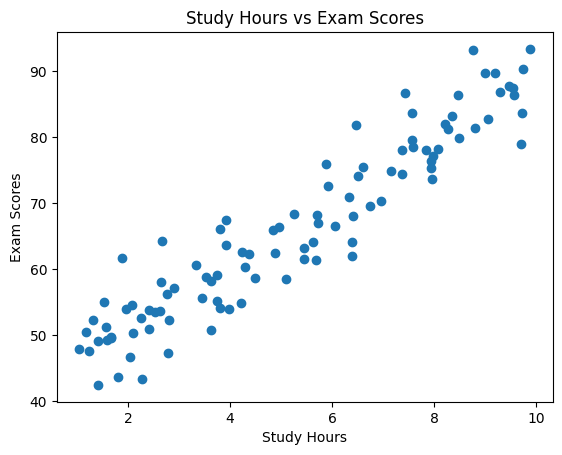

Iteration 0: Loss = 4556.104, m = 7.595, b = 1.323
Predictions: [61.83482133 86.99490409 77.44393393 71.62150866 52.29253603]
R² Score: 88.73588298722221


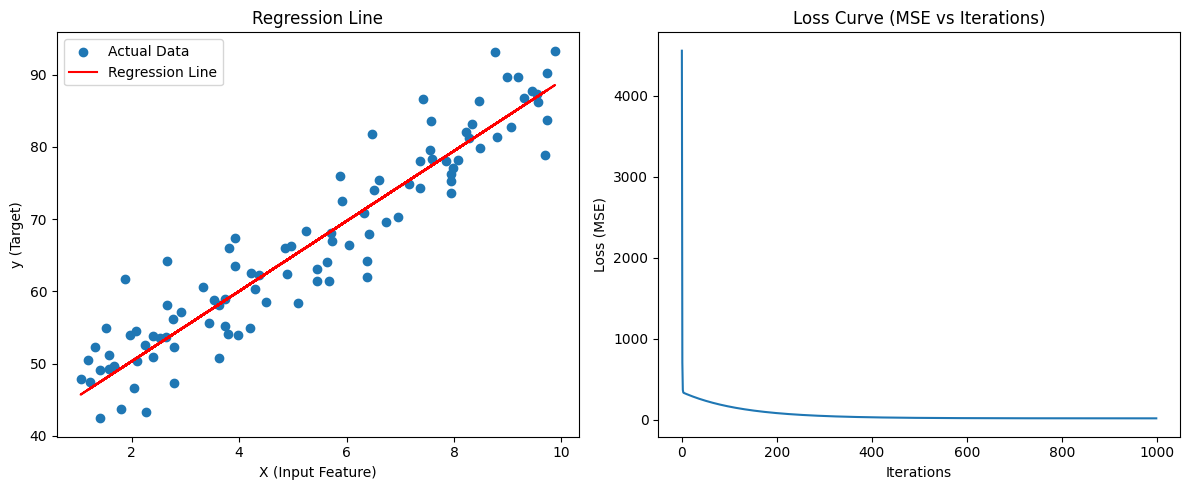

Iteration 0: Loss = 4556.104, m = 0.760, b = 0.132
Iteration 1000: Loss = 165.121, m = 8.794, b = 14.810
Iteration 2000: Loss = 84.965, m = 7.452, b = 23.599
Iteration 3000: Loss = 49.133, m = 6.555, b = 29.475
Iteration 4000: Loss = 33.114, m = 5.955, b = 33.404
Predictions: [60.30500158 89.10603761 78.17293225 71.5079351  49.38183787]
R² Score: 85.57497972488424


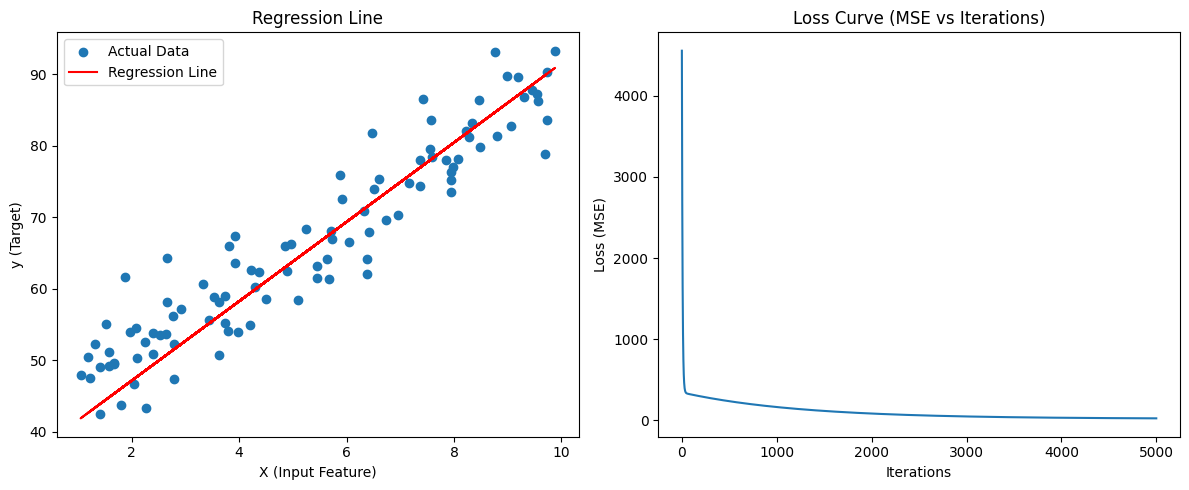

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


np.random.seed(42)
X = np.random.uniform(1, 10, 100)
y = 5 * X + 40 + np.random.randn(100) * 5

# Task 01
Data_set_dimension()

# Conclusion:**
# A linear regression model would be appropriate because it can effectively capture the relationship between study hours and exam scores.
'''First Experiment'''
# Task 02 & 03 Linear Regression Definition and train the model
LG = LinearRegression(learning_rate=0.01, iterations=1000)
LG.fit(X, y)

# Predictions
predictions = LG.predict(X)
print("Predictions:", predictions[:5])

# Score
r2 = LG.score(X, y)
print("R² Score:", r2*100)

# Predictions
y_pred = LG.predict(X)

#Task 04 Visulasing the prediction and Loss Values
Fig_LG()

'''Second Experiment'''
LG = LinearRegression(learning_rate=0.001, iterations=5000)
LG.fit(X, y)

# Predictions
predictions = LG.predict(X)
print("Predictions:", predictions[:5])

# Score
r2 = LG.score(X, y)
print("R² Score:", r2*100)

# Predictions
y_pred = LG.predict(X)

#Task 04 Visulasing the prediction and Loss Values
Fig_LG()

class LinearRegression:
    
    def __init__(self, learning_rate, iterations):
        """
        Initialize model parameters
        """
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.m = 0   # slope
        self.b = 0   # intercept
        self.loss_history = []
    
    
    def fit(self, X, y):
        """
        Train model using Gradient Descent
        """
        n = len(X)
        
        for i in range(self.iterations):
            
            # Predictions
            y_pred = self.m * X + self.b
            
            # Compute error
            error = y_pred - y
            
            # Compute gradients
            dm = (2/n) * np.sum(error * X)
            db = (2/n) * np.sum(error)
            
            # Update parameters
            self.m = self.m - self.learning_rate * dm
            self.b = self.b - self.learning_rate * db
            
            # Compute loss (MSE)
            loss = (1/n) * np.sum(error**2)
            self.loss_history.append(loss)
            
            # Print progress every 100 iterations
            if i % 1000 == 0:
                print(f"Iteration {i}: Loss = {loss:.3f}, m = {self.m:.3f}, b = {self.b:.3f}")
    
    
    def predict(self, X):
        """
        Predict using learned parameters
        """
        return self.m * X + self.b
    
    
    def score(self, X, y):
        """
        Calculate R² Score
        """
        y_pred = self.predict(X)
        
        ss_total = np.sum((y - np.mean(y))**2)
        ss_residual = np.sum((y - y_pred)**2)
        
        r2 = 1 - (ss_residual / ss_total)
        return r2


#Task 01
def Data_set_dimension():    

    print("Sample X (Study Hours):", X[:5])
    print("Sample y (Exam Scores):", y[:5])

    print("Shape of X:", X.shape,"Shape of y:", y.shape)

    # 🔹 Min
    print("Min of X:", round(X.min(),2),"Min of y:", round(y.min(),2))

    # 🔹 Max
    print("Max of X:", round(X.max(),2),"Max of y:", round(y.max(),2))

    # 🔹 Mean
    print("Mean of X:", round(X.mean(),2),"Mean of y:", round(y.mean(),2))

    # 🔹 Scatter Plot
    plt.scatter(X, y)
    plt.xlabel("Study Hours")
    plt.ylabel("Exam Scores")
    plt.title("Study Hours vs Exam Scores")
    plt.show()




def Fig_LG():
    # Create figure
    plt.figure(figsize=(12, 5))

    # =========================
    # Plot 1 — Regression Line
    # =========================
    plt.subplot(1, 2, 1)

    # Scatter plot (original data)
    plt.scatter(X, y, label="Actual Data")
    # Regression line (predicted)
    plt.plot(X, y_pred, color='red', label="Regression Line")
    plt.title("Regression Line")
    plt.xlabel("X (Input Feature)")
    plt.ylabel("y (Target)")
    plt.legend()

    # =========================
    # Plot 2 — Loss Curve
    # =========================
    plt.subplot(1, 2, 2)
    plt.plot(LG.loss_history)
    plt.title("Loss Curve (MSE vs Iterations)")
    plt.xlabel("Iterations")
    plt.ylabel("Loss (MSE)")

    # Layout adjustment
    plt.tight_layout()
    plt.show()

